# SIMC Weighting Sandbox

Minimal notebook for comparing exclusive and SIDIS SIMC contributions under different event-weight choices. Edit the config cell, then rerun from `load_samples()` downward.

In [293]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [294]:
def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pi0_analysis" / "root_analysis_env").exists():
            return path
    return start


REPO = find_repo_root()
ROOT_ENV = REPO / "pi0_analysis" / "root_analysis_env"

# Use either one combined SIMC file with is_exclusive labels, or set EXCL_FILE/SIDIS_FILE separately.
COMBINED_FILE = ROOT_ENV / "output" / "plots" / "x60_4b" / "production_wfpi0" / "simc_pi0_analysis_output_smeared.root"
DATA_FILE = ROOT_ENV / "output" / "plots" / "x60_4b" / "production_wfpi0" / "combined_branches_LH2_wfpi0.root"
EXCL_FILE = None
SIDIS_FILE = None

TREE_NAME = "simulation"
DATA_TREE_NAME = "physics"
MAX_EVENTS = None  # set to an integer for quick tests
SIM_SOURCES = ("excl", "sidis", "delta")
SOURCE_COLORS = {"excl": "red", "sidis": "green", "delta": "purple"}

BRANCH_ALIASES = {
    "mpi0": ["mpi0", "mpi0_all", "mgg", "mpgg"],
    "mmiss": ["mmiss", "mmiss_all", "mmiss_all_corr"],
    "full_weight": ["full_weight"],
    "siglab": ["siglab", "d5sig"],
    "sigcm": ["sigcm", "sig_cm"],
    "sample_label": ["is_exclusive"],
    "is_exclusive": ["is_exclusive"],
    "is_sidis": ["is_sidis"],
    "is_delta": ["is_delta"],
}
DATA_BRANCH_ALIASES = {
    "mpi0": ["mpi0_all", "mpi0", "mgg", "mpgg"],
    "mmiss": ["mmiss_all", "mmiss", "mmiss_all_corr"],
    "pi0_weight": ["pi0_weight"],
    "scale": ["scale"],
    # "data_exclusive": ["is_exclusive_ellipse_combined", "is_exclusive_ellipse", "is_exclusive"],
    "data_exclusive": ["is_exclusive_ellipse_combined"],
    "charge_uC": ["charge_uC", "charge_uc"],
    "run_number": ["run_number", "run"],
}
EXTRA_BRANCHES = ["Q2", "W", "t", "pt", "phi", "xB", "z"]

WEIGHT_FORMULAS = {
    "unit": "1",
    "full_weight": "full_weight",
    "full_weight_over_siglab": "safe_divide(full_weight, siglab)",
    "siglab": "siglab",
    "sigcm": "sigcm",
}
ACTIVE_WEIGHT = "full_weight"

EXCL_SCALE = 1.0
SIDIS_SCALE = 1.0
DELTA_SCALE = 1.0
DATA_SCALE = 1.0
EXCL_PLOT_SCALE = 0.52
SIDIS_PLOT_SCALE = 0.43
DELTA_PLOT_SCALE = 0.0004
APPLY_DATA_EXCLUSIVE_CUT = False
CLIP_WEIGHT_QUANTILE = None  # e.g. 0.999 to tame extreme tails while experimenting

MPI0_BINS = np.linspace(0.05, 0.25, 81)
MMISS_BINS = np.linspace(0.2, 2.2, 101)
MPI0_WINDOW = (0.10, 0.17)
MMISS_WINDOW = (0.75, 1.15)

In [295]:
def pick_tree(root_file, tree_name=TREE_NAME):
    if tree_name in root_file:
        return root_file[tree_name]
    for key in root_file.keys():
        obj = root_file[key]
        if hasattr(obj, "arrays"):
            return obj
    raise KeyError(f"No TTree found in {root_file.file_path}")


def first_available(available, names):
    for name in names:
        if name in available:
            return name
    return None


def read_sim_file(path, source=None):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    with uproot.open(path) as root_file:
        tree = pick_tree(root_file)
        available = set(tree.keys())

        branch_map = {}
        for canonical, aliases in BRANCH_ALIASES.items():
            found = first_available(available, aliases)
            if found is not None:
                branch_map[canonical] = found

        for name in EXTRA_BRANCHES:
            if name in available:
                branch_map[name] = name

        missing = [name for name in ("mpi0", "mmiss") if name not in branch_map]
        if missing:
            raise KeyError(f"{path} is missing required branches/aliases: {missing}")

        arrays = tree.arrays(list(branch_map.values()), entry_stop=MAX_EVENTS, library="np")

    frame = pd.DataFrame({canonical: arrays[branch] for canonical, branch in branch_map.items()})
    frame["file"] = path.name
    if source is not None:
        frame["source"] = source
    return frame


def read_data_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    with uproot.open(path) as root_file:
        tree = pick_tree(root_file, DATA_TREE_NAME)
        available = set(tree.keys())

        branch_map = {}
        for canonical, aliases in DATA_BRANCH_ALIASES.items():
            found = first_available(available, aliases)
            if found is not None:
                branch_map[canonical] = found

        for name in EXTRA_BRANCHES:
            if name in available:
                branch_map[name] = name

        missing = [name for name in ("mpi0", "mmiss", "pi0_weight") if name not in branch_map]
        if missing:
            raise KeyError(f"{path} is missing required data branches/aliases: {missing}")

        arrays = tree.arrays(list(branch_map.values()), entry_stop=MAX_EVENTS, library="np")

    frame = pd.DataFrame({canonical: arrays[branch] for canonical, branch in branch_map.items()})
    frame["file"] = path.name
    if "scale" not in frame:
        frame["scale"] = 1.0
    if "data_exclusive" not in frame:
        frame["data_exclusive"] = 1.0

    charge_fraction = np.ones(len(frame), dtype=float)
    if "charge_uC" in frame and "run_number" in frame:
        charge_uC = pd.to_numeric(frame["charge_uC"], errors="coerce").to_numpy(dtype=float)
        run_number = pd.to_numeric(frame["run_number"], errors="coerce").to_numpy(dtype=float)
        valid_charge = np.isfinite(charge_uC) & (charge_uC > 0.0) & np.isfinite(run_number)
        if np.any(valid_charge):
            run_charge = pd.DataFrame({
                "run_number": run_number[valid_charge].astype(np.int64),
                "charge_uC": charge_uC[valid_charge],
            }).drop_duplicates("run_number")
            total_charge_uC = run_charge["charge_uC"].sum()
            if np.isfinite(total_charge_uC) and total_charge_uC > 0.0:
                charge_fraction[valid_charge] = charge_uC[valid_charge] / total_charge_uC
    frame["charge_fraction"] = charge_fraction

    exclusive_factor = frame["data_exclusive"].astype(float) if APPLY_DATA_EXCLUSIVE_CUT else 1.0
    frame["weight"] = DATA_SCALE * frame["pi0_weight"].astype(float) * frame["scale"].astype(float) * charge_fraction * exclusive_factor
    frame["weight"] = np.where(np.isfinite(frame["weight"]), frame["weight"], 0.0)
    return frame


def load_samples():
    if EXCL_FILE or SIDIS_FILE:
        parts = []
        if EXCL_FILE:
            parts.append(read_sim_file(EXCL_FILE, "excl"))
        if SIDIS_FILE:
            parts.append(read_sim_file(SIDIS_FILE, "sidis"))
        samples = pd.concat(parts, ignore_index=True)
    else:
        samples = read_sim_file(COMBINED_FILE)
        if {"is_exclusive", "is_sidis", "is_delta"}.issubset(samples.columns):
            flags = samples[["is_exclusive", "is_sidis", "is_delta"]].fillna(0).astype(float)
            source_values = np.array(["unlabeled"] * len(samples), dtype=object)
            source_values[flags["is_exclusive"].to_numpy() != 0] = "excl"
            source_values[flags["is_sidis"].to_numpy() != 0] = "sidis"
            source_values[flags["is_delta"].to_numpy() != 0] = "delta"
            samples["source"] = source_values
            samples = samples[samples["source"] != "unlabeled"].copy()
        elif "sample_label" in samples:
            samples["source"] = np.where(samples["sample_label"].astype(int) == 1, "excl", "sidis")
        else:
            raise KeyError("Combined mode needs is_exclusive/is_sidis/is_delta branches, or set EXCL_FILE/SIDIS_FILE.")

    for needed, default in (("full_weight", 1.0),):
        if needed not in samples:
            samples[needed] = default

    print(f"Loaded {len(samples):,} events from {samples['file'].nunique()} file(s)")
    print(samples.groupby("source").size().rename("events"))
    print("\nColumns:", ", ".join(samples.columns))
    return samples


def load_data():
    data = read_data_file(DATA_FILE)
    print(f"Loaded {len(data):,} data events from {DATA_FILE.name}")
    formula = "pi0_weight * scale * charge_fraction"
    if APPLY_DATA_EXCLUSIVE_CUT:
        formula += " * data_exclusive"
    print(f"Data weight: {formula}")
    print("\nColumns:", ", ".join(data.columns))
    return data


def safe_divide(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.zeros_like(num, dtype=float)
    mask = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-20)
    out[mask] = num[mask] / den[mask]
    return out


def evaluate_weight(frame, formula_name=ACTIVE_WEIGHT):
    formula = WEIGHT_FORMULAS[formula_name]
    local_values = {col: frame[col].to_numpy(dtype=float) for col in frame.columns if pd.api.types.is_numeric_dtype(frame[col])}
    local_values["safe_divide"] = safe_divide
    try:
        weight = eval(formula, {"__builtins__": {}, "np": np}, local_values)
    except NameError as exc:
        raise KeyError(f"Weight formula '{formula}' needs a branch that was not loaded") from exc

    weight = np.asarray(weight, dtype=float)
    if weight.ndim == 0:
        weight = np.full(len(frame), float(weight))
    weight = np.where(np.isfinite(weight), weight, 0.0)
    if CLIP_WEIGHT_QUANTILE is not None and len(weight):
        lo, hi = np.nanquantile(weight, [1.0 - CLIP_WEIGHT_QUANTILE, CLIP_WEIGHT_QUANTILE])
        weight = np.clip(weight, lo, hi)
    return weight


def source_weights(frame, formula_name=ACTIVE_WEIGHT):
    weight = evaluate_weight(frame, formula_name)
    scale_map = {"excl": EXCL_SCALE, "sidis": SIDIS_SCALE, "delta": DELTA_SCALE}
    scale = frame["source"].map(scale_map).fillna(1.0).to_numpy(dtype=float)
    return weight * scale

In [296]:
samples = load_samples()
data = load_data()

# For de-modeling, this is the recommended form. If siglab is missing, try another ACTIVE_WEIGHT above.
samples["weight"] = source_weights(samples, ACTIVE_WEIGHT)
summary_columns = [col for col in ["source", "is_exclusive", "is_sidis", "is_delta", "mpi0", "mmiss", "full_weight", "siglab", "sigcm", "weight"] if col in samples]
samples[summary_columns].describe(include="all")

Loaded 411,246 events from 1 file(s)
source
delta    141008
excl     155613
sidis    114625
Name: events, dtype: int64

Columns: mpi0, mmiss, full_weight, siglab, sample_label, is_exclusive, is_sidis, is_delta, Q2, W, t, pt, phi, xB, z, file, source
Loaded 1,295,923 data events from combined_branches_LH2_wfpi0.root
Data weight: pi0_weight * scale * charge_fraction

Columns: mpi0, mmiss, pi0_weight, scale, data_exclusive, charge_uC, run_number, Q2, W, t, pt, phi, xB, z, file, charge_fraction, weight


,source,is_exclusive,is_sidis,is_delta,mpi0,mmiss,full_weight,siglab,weight
count,411246,411246.000000,411246.000000,411246.000000,411246.000000,411246.000000,411246.000000,4.112460e+05,411246.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,excl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,155613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.378394,0.278726,0.342880,0.132019,1.214449,0.040499,2.896749e-07,0.040499
std,NaN,0.484987,0.448373,0.474672,0.006198,0.262174,0.070378,3.618617e-07,0.070378
min,NaN,0.000000,0.000000,0.000000,0.024176,0.563367,0.000003,6.798007e-11,0.000003
25%,NaN,0.000000,0.000000,0.000000,0.130148,0.989797,0.000366,1.419568e-09,0.000366
50%,NaN,0.000000,0.000000,0.000000,0.133042,1.193207,0.000689,1.283294e-07,0.000689
75%,NaN,1.000000,1.000000,1.000000,0.135461,1.352173,0.064154,4.689694e-07,0.064154


In [297]:
def weighted_sum(frame, mask=None):
    if mask is None:
        mask = np.ones(len(frame), dtype=bool)
    return float(np.sum(frame.loc[mask, "weight"]))


def contribution_table(frame):
    rows = []
    masks = {
        "all": np.ones(len(frame), dtype=bool),
        "mpi0_window": frame["mpi0"].between(*MPI0_WINDOW).to_numpy(),
        "mmiss_window": frame["mmiss"].between(*MMISS_WINDOW).to_numpy(),
        "both_windows": (frame["mpi0"].between(*MPI0_WINDOW) & frame["mmiss"].between(*MMISS_WINDOW)).to_numpy(),
    }
    sources = frame["source"].to_numpy()
    for region, mask in masks.items():
        values = {source: weighted_sum(frame, mask & (sources == source)) for source in SIM_SOURCES}
        total = sum(values.values())
        row = {
            "region": region,
            **values,
            "total = excl + sidis + delta": total,
        }
        for source in SIM_SOURCES:
            row[f"{source}_fraction"] = values[source] / total if total else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def region_masks(frame):
    return {
        "all": np.ones(len(frame), dtype=bool),
        "mpi0_window": frame["mpi0"].between(*MPI0_WINDOW).to_numpy(),
        "mmiss_window": frame["mmiss"].between(*MMISS_WINDOW).to_numpy(),
        "both_windows": (frame["mpi0"].between(*MPI0_WINDOW) & frame["mmiss"].between(*MMISS_WINDOW)).to_numpy(),
    }


def plot_scale_map(excl_scale=EXCL_PLOT_SCALE, sidis_scale=SIDIS_PLOT_SCALE, delta_scale=DELTA_PLOT_SCALE):
    return {"excl": excl_scale, "sidis": sidis_scale, "delta": delta_scale}


def data_sim_scale_table(sim_frame, data_frame, excl_scale=EXCL_PLOT_SCALE, sidis_scale=SIDIS_PLOT_SCALE, delta_scale=DELTA_PLOT_SCALE):
    rows = []
    sim_masks = region_masks(sim_frame)
    data_masks = region_masks(data_frame)
    sim_source = sim_frame["source"].to_numpy()
    scales = plot_scale_map(excl_scale, sidis_scale, delta_scale)
    for region in sim_masks:
        region_mask = sim_masks[region]
        sim_values = {source: scales[source] * weighted_sum(sim_frame, region_mask & (sim_source == source)) for source in SIM_SOURCES}
        sim_total = sum(sim_values.values())
        data_total = weighted_sum(data_frame, data_masks[region])
        rows.append({
            "region": region,
            "data": data_total,
            **{f"scaled_{source}": value for source, value in sim_values.items()},
            "sim_total = excl + sidis + delta": sim_total,
            "data / sim_total": data_total / sim_total if sim_total else np.nan,
            "sim / data": sim_total / data_total if data_total else np.nan,
        })
    return pd.DataFrame(rows)


display(contribution_table(samples))
data_sim_scale_table(samples, data, EXCL_PLOT_SCALE, SIDIS_PLOT_SCALE, DELTA_PLOT_SCALE)

,region,excl,sidis,delta,total = excl + sidis + delta,excl_fraction,sidis_fraction,delta_fraction
0,all,56.047308,88.810969,16510.088198,16654.946476,0.003365,0.005332,0.991302
1,mpi0_window,55.651891,88.445161,16413.290002,16557.387054,0.003361,0.005342,0.991297
2,mmiss_window,48.554462,5.808367,3537.677767,3592.040596,0.013517,0.001617,0.984866
3,both_windows,48.549715,5.807975,3537.534866,3591.892556,0.013516,0.001617,0.984867


,region,data,scaled_excl,scaled_sidis,scaled_delta,sim_total = excl + sidis + delta,data / sim_total,sim / data
0,all,145.515643,29.144600,38.188717,6.604035,73.937352,1.968094,0.508106
1,mpi0_window,138.654718,28.938983,38.031419,6.565316,73.535719,1.885542,0.530351
2,mmiss_window,30.335288,25.248320,2.497598,1.415071,29.160989,1.040269,0.961289
3,both_windows,29.991126,25.245852,2.497429,1.415014,29.158295,1.028562,0.972231


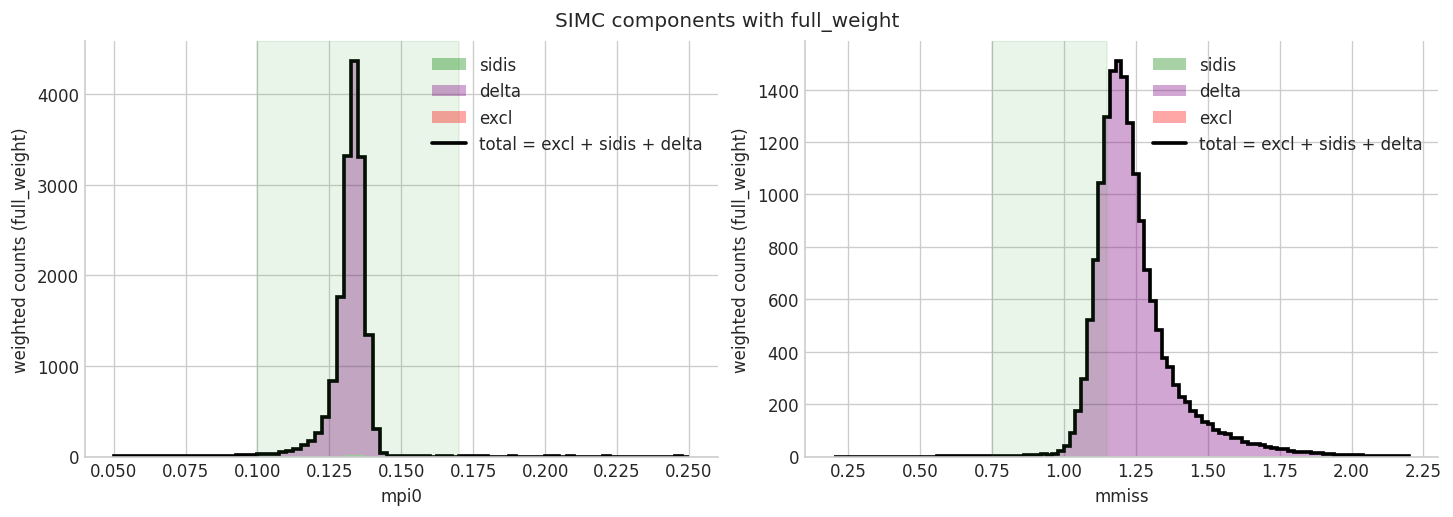

In [298]:
def hist_by_source(frame, variable, bins, formula_name=ACTIVE_WEIGHT):
    local = frame.copy()
    local["weight"] = source_weights(local, formula_name)
    out = {}
    for source in SIM_SOURCES:
        sub = local[local["source"] == source]
        out[source], edges = np.histogram(sub[variable], bins=bins, weights=sub["weight"])
    out["total"] = sum(out[source] for source in SIM_SOURCES)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, edges, out


def plot_components(frame, variable, bins, formula_name=ACTIVE_WEIGHT, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    centers, edges, hist = hist_by_source(frame, variable, bins, formula_name)
    baseline = np.zeros_like(hist["total"])
    for source in ("sidis", "delta", "excl"):
        top = baseline + hist[source]
        ax.stairs(top, edges, baseline=baseline, fill=True, alpha=0.35,
                  color=SOURCE_COLORS[source], label=source)
        baseline = top
    total = hist["total"]
    ax.stairs(total, edges, color="black", linewidth=2.2,
              label="total = excl + sidis + delta")
    ax.set_xlabel(variable)
    ax.set_ylabel(f"weighted counts ({formula_name})")
    ax.legend(frameon=False)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
plot_components(samples, "mpi0", MPI0_BINS, ACTIVE_WEIGHT, axes[0])
plot_components(samples, "mmiss", MMISS_BINS, ACTIVE_WEIGHT, axes[1])
axes[0].axvspan(*MPI0_WINDOW, color="tab:green", alpha=0.10)
axes[1].axvspan(*MMISS_WINDOW, color="tab:green", alpha=0.10)
fig.suptitle(f"SIMC components with {ACTIVE_WEIGHT}")
plt.show()

,variable,integral data / sim_total,binned least-squares factor
0,mpi0,1.946382,1.686216
1,mmiss,1.951575,1.503795


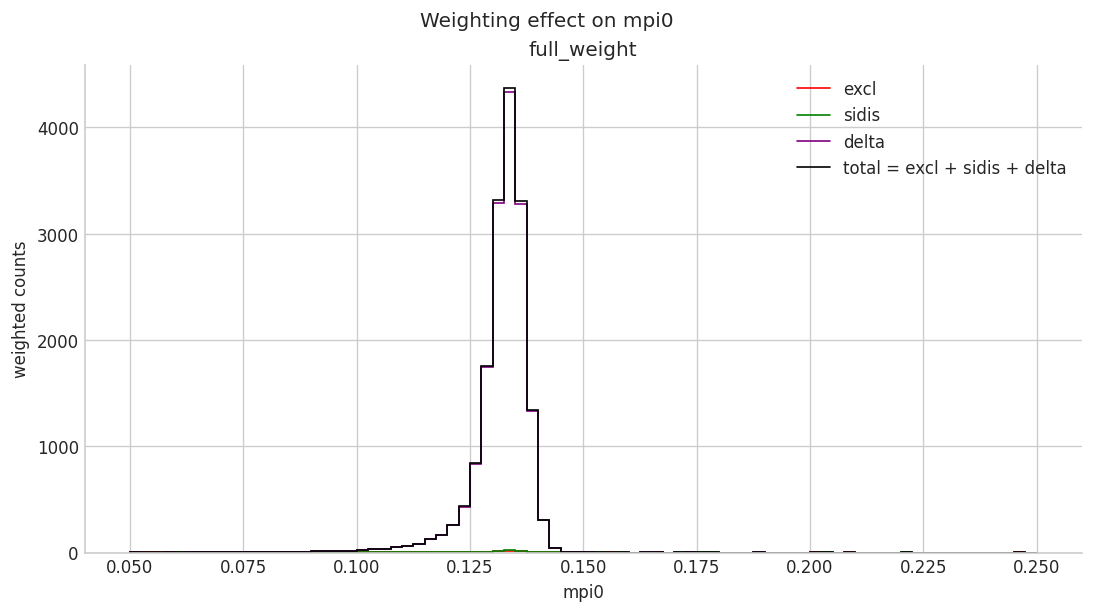

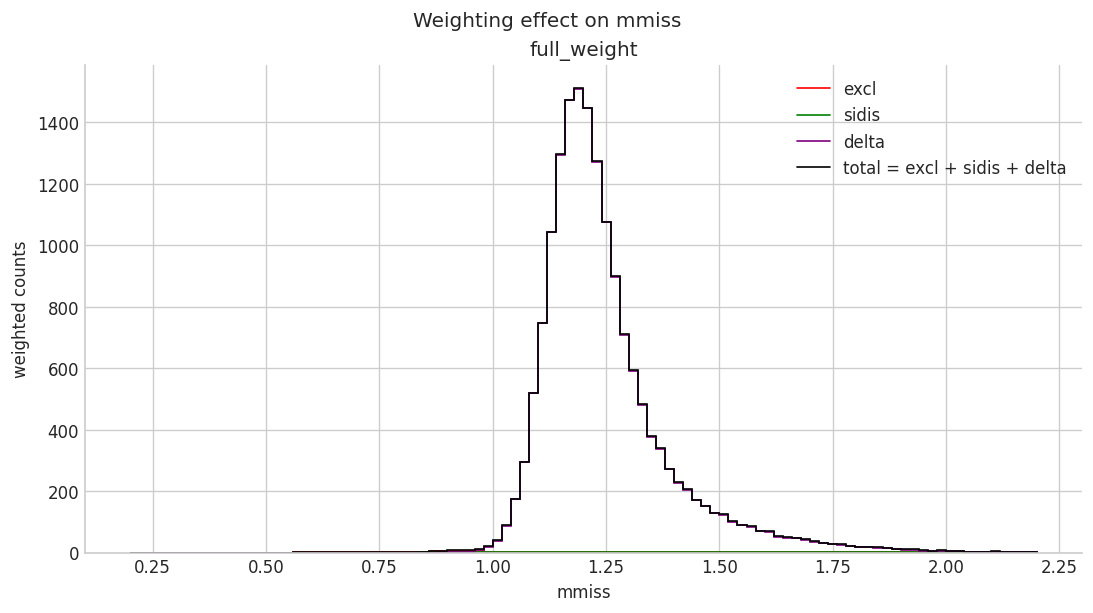

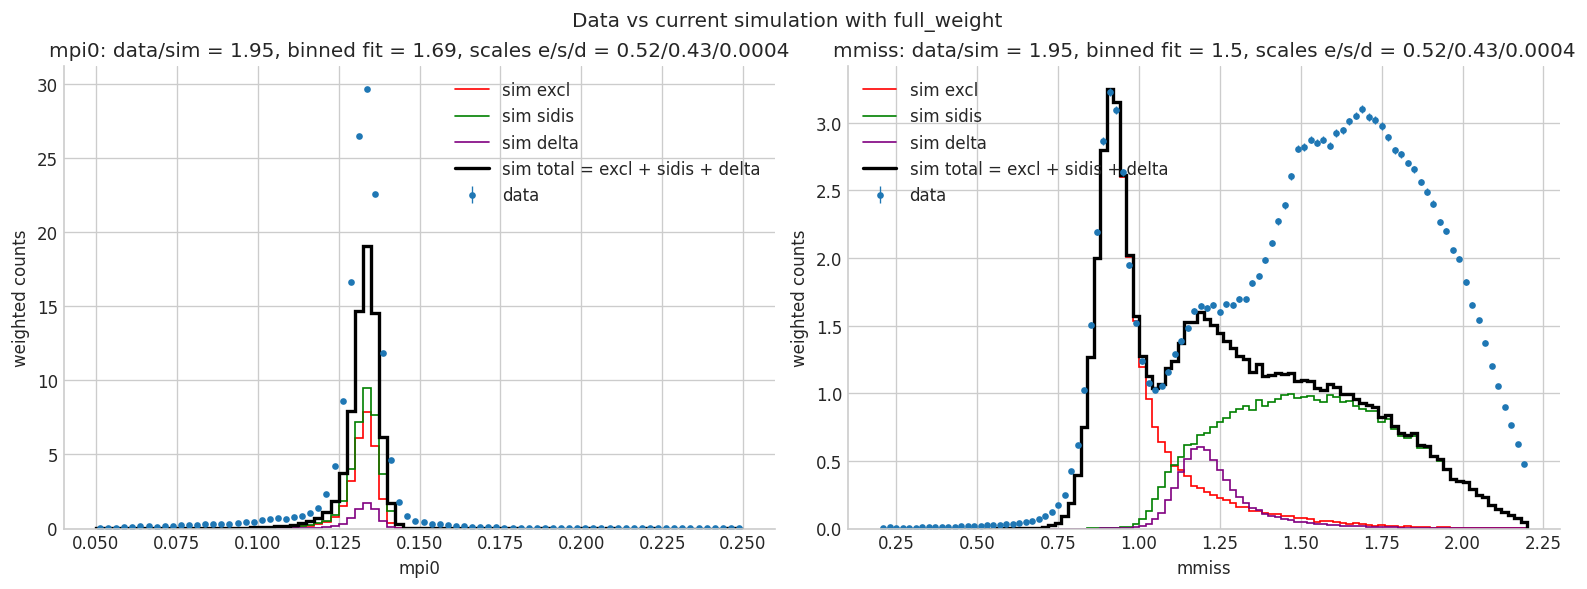

In [299]:
def compare_weight_formulas(frame, variable="mmiss", bins=MMISS_BINS, formulas=None):
    if formulas is None:
        # formulas = ["unit", "full_weight", "full_weight_over_siglab"]
        formulas = ["full_weight"]
    fig, axes = plt.subplots(len(formulas), 1, figsize=(9.0, 5.0 * len(formulas)),
                             sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, formula_name in zip(axes, formulas):
        _, edges, hist = hist_by_source(frame, variable, bins, formula_name)
        for source in SIM_SOURCES:
            ax.stairs(hist[source], edges, color=SOURCE_COLORS[source], linewidth=1.0, label=source)
        ax.stairs(hist["total"], edges, color="black", linewidth=1.0, label="total = excl + sidis + delta")
        ax.set_ylabel("weighted counts")
        ax.set_title(formula_name)
        ax.legend(frameon=False)

    axes[-1].set_xlabel(variable)
    fig.suptitle(f"Weighting effect on {variable}")
    return axes


def hist_data(frame, variable, bins):
    counts, edges = np.histogram(frame[variable], bins=bins, weights=frame["weight"])
    counts2, _ = np.histogram(frame[variable], bins=bins, weights=frame["weight"] ** 2)
    centers = 0.5 * (edges[:-1] + edges[1:])
    errors = np.sqrt(counts2)
    return centers, edges, counts, errors


def binned_scale_factor(data_hist, sim_hist):
    mask = np.isfinite(data_hist) & np.isfinite(sim_hist) & (sim_hist > 0)
    den = np.sum(sim_hist[mask] ** 2)
    return np.sum(data_hist[mask] * sim_hist[mask]) / den if den else np.nan


def plot_data_sim_agreement(sim_frame, data_frame, variable, bins, formula_name=ACTIVE_WEIGHT, ax=None, excl_scale=EXCL_PLOT_SCALE, sidis_scale=SIDIS_PLOT_SCALE, delta_scale=DELTA_PLOT_SCALE):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.8))
    centers, edges, hist = hist_by_source(sim_frame, variable, bins, formula_name)
    data_centers, _, data_counts, data_errors = hist_data(data_frame, variable, bins)
    scales = plot_scale_map(excl_scale, sidis_scale, delta_scale)
    sim_scaled = {source: scales[source] * hist[source] for source in SIM_SOURCES}
    total = sum(sim_scaled.values())

    for source in SIM_SOURCES:
        ax.stairs(sim_scaled[source], edges, color=SOURCE_COLORS[source], linewidth=1.0, label=f"sim {source}")
    ax.stairs(total, edges, color="black", linewidth=2.0, label="sim total = excl + sidis + delta")
    ax.errorbar(data_centers, data_counts, yerr=data_errors, fmt="o", markersize=3.0,
                color="tab:blue", ecolor="tab:blue", elinewidth=0.8, capsize=0,
                label="data")
    scale = np.sum(data_counts) / np.sum(total) if np.sum(total) else np.nan
    shape_scale = binned_scale_factor(data_counts, total)
    ax.set_title(f"{variable}: data/sim = {scale:.3g}, binned fit = {shape_scale:.3g}, scales e/s/d = {excl_scale:.3g}/{sidis_scale:.3g}/{delta_scale:.3g}")
    ax.set_xlabel(variable)
    ax.set_ylabel("weighted counts")
    ax.legend(frameon=False)
    return ax


def binned_scale_table(sim_frame, data_frame, formula_name=ACTIVE_WEIGHT, excl_scale=EXCL_PLOT_SCALE, sidis_scale=SIDIS_PLOT_SCALE, delta_scale=DELTA_PLOT_SCALE):
    rows = []
    for variable, bins in (("mpi0", MPI0_BINS), ("mmiss", MMISS_BINS)):
        _, _, sim_hist = hist_by_source(sim_frame, variable, bins, formula_name)
        _, _, data_hist, _ = hist_data(data_frame, variable, bins)
        scales = plot_scale_map(excl_scale, sidis_scale, delta_scale)
        sim_total = sum(scales[source] * sim_hist[source] for source in SIM_SOURCES)
        rows.append({
            "variable": variable,
            "integral data / sim_total": np.sum(data_hist) / np.sum(sim_total) if np.sum(sim_total) else np.nan,
            "binned least-squares factor": binned_scale_factor(data_hist, sim_total),
        })
    return pd.DataFrame(rows)


compare_weight_formulas(samples, "mpi0", MPI0_BINS)
compare_weight_formulas(samples, "mmiss", MMISS_BINS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
plot_data_sim_agreement(samples, data, "mpi0", MPI0_BINS, ACTIVE_WEIGHT, axes[0], excl_scale=EXCL_PLOT_SCALE, sidis_scale=SIDIS_PLOT_SCALE, delta_scale=DELTA_PLOT_SCALE)
plot_data_sim_agreement(samples, data, "mmiss", MMISS_BINS, ACTIVE_WEIGHT, axes[1], excl_scale=EXCL_PLOT_SCALE, sidis_scale=SIDIS_PLOT_SCALE, delta_scale=DELTA_PLOT_SCALE)
fig.suptitle(f"Data vs current simulation with {ACTIVE_WEIGHT}")
display(binned_scale_table(samples, data, ACTIVE_WEIGHT, EXCL_PLOT_SCALE, SIDIS_PLOT_SCALE, DELTA_PLOT_SCALE))
plt.show()

Notes:

- The default de-modeled SIMC weight is `full_weight / siglab`.
- The default data weight is `pi0_weight * scale * charge_fraction`; `APPLY_DATA_EXCLUSIVE_CUT` is `False`.
- The data/sim factor tables use `sim_total = excl + sidis + delta`.
- Processed SIMC source labels come from `is_exclusive`, `is_sidis`, and `is_delta` when available.
- To test `sigcm`, make sure the branch exists in the selected tree and set `ACTIVE_WEIGHT = "sigcm"` or add a custom entry to `WEIGHT_FORMULAS`.
- `EXCL_PLOT_SCALE`, `SIDIS_PLOT_SCALE`, and `DELTA_PLOT_SCALE` only affect data/simulation agreement plots and factor tables.